# Imports

In [29]:
import seaborn as sns
from matplotlib import pyplot as plt

from alphaanalysis.plot.gam import get_sig_intervals
import utils

# Data Base

In [30]:
from djimaging.user.alpha.utils import access_database

indicator = 'calcium'

database = access_database.access_database(indicator, use_sql=False)

Loading calcium data from: /gpfs01/berens/user/joesterle/projects/alpha/__public_s-on-alpha-regional/gnode/s-on-alpha-regional/database-exports/Ran/sONa_calcium


In [31]:
df = database.get_tri_df()
df = df.drop(columns=['chirp_avg', 'trf'])

# Plot

In [32]:
from alphaanalysis import plot as plota
plota.set_rc_params()

In [33]:
order = plota.get_order(indicator=indicator)
palette = plota.get_palette(indicator=indicator)
colors = [palette[group] for group in order]

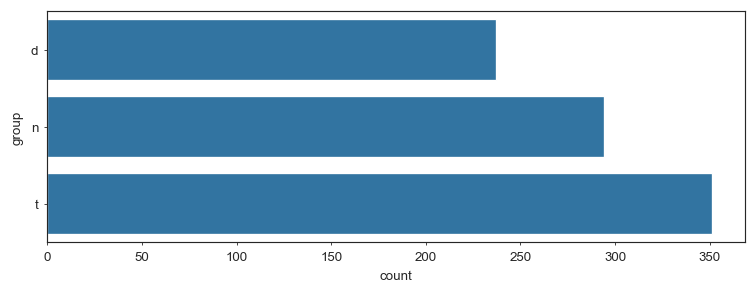

In [34]:
sns.countplot(data=df, y="group");

# Fit GAM

In [35]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [36]:
%%R

rm(list=ls()) 

## R imports

In [37]:
#!sudo apt-get update
#!sudo apt-get install -y libfontconfig1-dev
# !sudo apt-get install -y libcairo2-dev

In [38]:
#!sudo Rscript -e 'install.packages("IRdisplay")'
#!sudo Rscript -e 'install.packages("dplyr")'
#!sudo Rscript -e 'install.packages("parallel")'
#!sudo Rscript -e 'install.packages("ggplot2")'
#!sudo Rscript -e 'install.packages("nlme")'
#!sudo Rscript -e 'install.packages("mgcv")'
#!sudo Rscript -e 'install.packages("hrbrthemes")'
#!sudo Rscript -e 'install.packages("ggthemes")'
#!sudo Rscript -e 'install.packages("itsadug")'
#!sudo Rscript -e 'install.packages("png")'
#!sudo Rscript -e 'install.packages("xtable")'
#!sudo Rscript -e 'install.packages("tidymv")'
#!sudo Rscript -e 'install.packages("cowplot")'

In [39]:
%%R

library("IRdisplay")
library("dplyr")
library('parallel')
library('ggplot2')
library("nlme")
library("mgcv")
# library("hrbrthemes")
library("ggthemes")
library("itsadug")
library("png")
library("xtable")
library("tidymv")
library("cowplot")

# Import R df

In [40]:
%%R -i df

df$group <- factor(df$group)
df$cell_id <- factor(df$cell_id)
df$field_id <- factor(df$field_id)


df <- df[df$soma_dist <= 200, ]

head(df)

  experimenter   date exp_num field   cond1 roi_id      cell_id        field_id
0          Ran 736855       1    D1 control      1 2018-06-10_1 2018-06-10_1_D1
1          Ran 736855       1    D1 control      2 2018-06-10_1 2018-06-10_1_D1
2          Ran 736855       1    D1 control      4 2018-06-10_1 2018-06-10_1_D1
3          Ran 736855       1    D1 control      5 2018-06-10_1 2018-06-10_1_D1
4          Ran 736855       1    D1 control      6 2018-06-10_1 2018-06-10_1_D1
5          Ran 736855       1    D1 control      7 2018-06-10_1 2018-06-10_1_D1
  lChirp gChirp chirp_tri     qidx min_qidx chirp_surround_index soma_dist
0 lChirp gChirp  0.175672 0.459209 0.333333           -0.0979975   140.978
1 lChirp gChirp  0.560227 0.371802 0.333333           -0.3303210   112.357
2 lChirp gChirp  0.113526 0.401111 0.333333            0.5890920   137.378
3 lChirp gChirp  0.290542 0.385104 0.333333           -0.0669644   124.131
4 lChirp gChirp  0.293814 0.372392 0.333333           -0.1911890 

## Helper functions

In [41]:
%%R

display_model <- function(m){
    print(summary(m));
    tabs <- capture.output(gamtabs(m, type="HTML"));
    display_html(tabs);
}

## Plot raw data

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 168 rows containing missing values (`geom_point()`). 



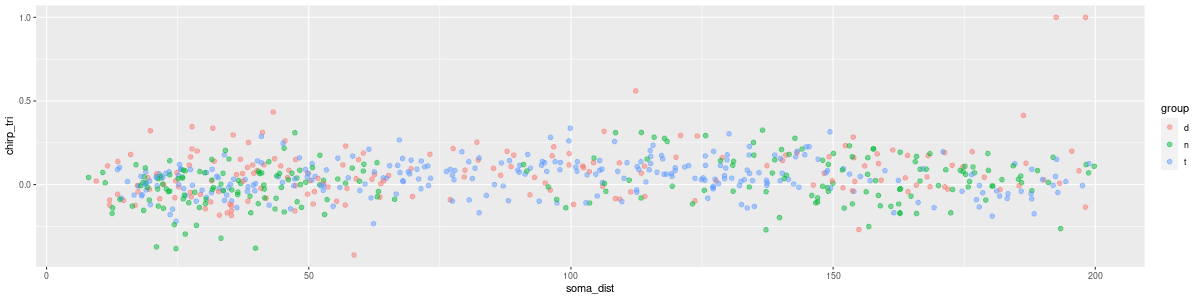

In [42]:
%%R -w 1200 -h 300

p1 <- ggplot(aes(x=soma_dist, y=chirp_tri, color=group), data=df)  +
    geom_point(alpha=.5, size=2)

p1

# GAMs

## Noise TRi

In [43]:
%%R

m1  <- gam(chirp_tri ~ group + s(soma_dist, k=4, bs="cr"), data=df)
m2  <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=4, bs="cr"), data=df)
m3a <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=4, bs="cr") + s(cell_id, bs="re"), data=df)
m3b <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=4, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m4a <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df)
m4b <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m5a <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df)
m5b <- gam(chirp_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')

In [44]:
%%R
BIC(m1, m2, m3a, m3b, m4a, m4b, m5a, m5b)

           df       BIC
m1   6.180261 -800.4286
m2   9.259598 -798.6212
m3a 24.175863 -896.3083
m3b 24.903444 -998.0662
m4a 27.021152 -890.3325
m4b 25.857727 -993.7823
m5a 27.169922 -889.5387
m5b 25.976951 -993.1509


In [45]:
%%R
anova(m1, m2, m3a, m4a, m5a, test="F")

Analysis of Deviance Table

Model 1: chirp_tri ~ group + s(soma_dist, k = 4, bs = "cr")
Model 2: chirp_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr")
Model 3: chirp_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")
Model 4: chirp_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 5: chirp_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev       Df Deviance       F    Pr(>F)    
1    661.44    11.0742                                        
2    657.97    10.7758  3.46481  0.29836  6.9886 4.841e-05 ***
3    642.29     8.0480 15.68497  2.72782 14.1142 < 2.2e-16 ***
4    638.59     7.8983  3.69473  0.14973  3.2890   0.01331 *  
5    638.15     7.8962  0.43794  0.00206  0.3810   0.37393    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [46]:
%%R
anova(m3b, m4b, m5b, test="F")

Analysis of Deviance Table

Model 1: chirp_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")
Model 2: chirp_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 3: chirp_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev      Df Deviance Pr(>Chi)
1    642.90    -1160.0                          
2    641.55    -1161.9 1.34105  1.92159   0.2374
3    641.38    -1162.1 0.17763  0.14395   0.1767



Family: Scaled t(4.591,0.082) 
Link function: identity 

Formula:
chirp_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.04889    0.04203   1.163    0.245
groupn      -0.05787    0.05682  -1.018    0.309
groupt      -0.01367    0.05670  -0.241    0.809

Approximate significance of smooth terms:
                       edf Ref.df Chi.sq  p-value    
s(soma_dist):groupd  1.001  1.002  18.96 1.34e-05 ***
s(soma_dist):groupn  1.794  2.186  21.49 3.69e-05 ***
s(soma_dist):groupt  2.390  2.737  32.69 4.85e-06 ***
s(cell_id)          13.517 14.000 305.60  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.286   Deviance explained = 27.6%
-REML = -524.09  Scale est. = 1         n = 667

Method: REML   Optimizer: outer newton
full convergence after 9 iterations.
Gradient range [-0.0001837495,0.001074857]
(score -524.0923 & sc

In addition: Warning message:
In getOption("jupyter.base_display_func")(data, metadata) :
  IRdisplay can only be used from the IPython R kernel and R magic.


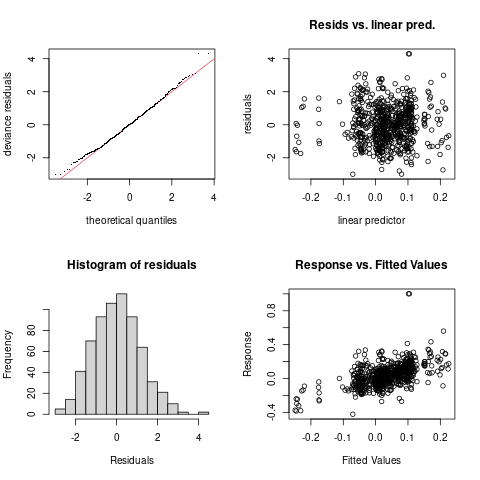

In [47]:
%%R
m <- m3b
display_model(m)
gam.check(m)

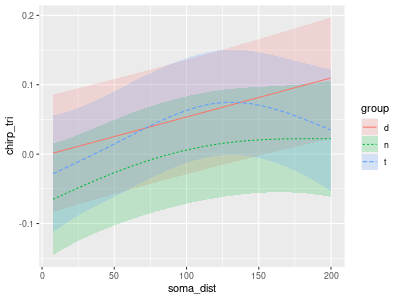

In [48]:
%%R -w 400 -h 300

p1 <- plot_smooths(model=m, series=soma_dist, comparison=group)
plot(p1, ylim=c(0, 60))

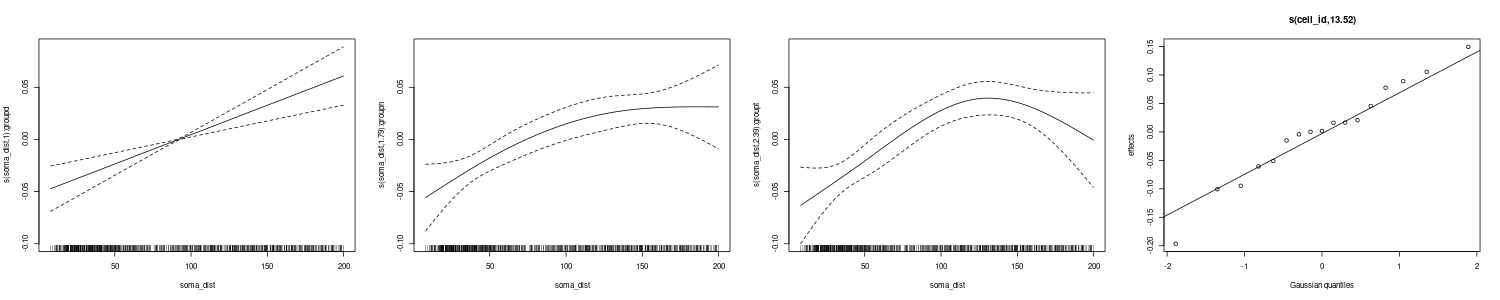

In [49]:
%%R -w 1500 -h 300
par(mfrow = c(1,4))
plot(m)

### Plot fits

In [50]:
%%R

r_df_pred = predict_gam(m, exclude_terms=s(cell_id, bs="re"))
head(r_df_pred)

# A tibble: 6 x 5
  group soma_dist cell_id           fit se.fit
  <fct>     <dbl> <fct>           <dbl>  <dbl>
1 d          7.62 2018-06-10_1  0.00143 0.0432
2 n          7.62 2018-06-10_1 -0.0651  0.0409
3 t          7.62 2018-06-10_1 -0.0284  0.0429
4 d         11.5  2018-06-10_1  0.00364 0.0431
5 n         11.5  2018-06-10_1 -0.0614  0.0403
6 t         11.5  2018-06-10_1 -0.0245  0.0419


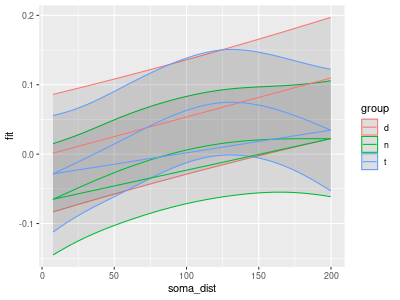

In [51]:
%%R -w 400 -h 300

predict_gam(m, exclude_terms=s(cell_id, bs="re")) %>%
    ggplot(aes(soma_dist, fit, col=group)) +
    geom_smooth_ci()

### Plot differences 

[1] 0.9916667
[1] 2.39398
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 8.027180 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

Difference is not significant.
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 8.027180 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

Difference is not significant.
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 8.027180 to 199.793000. 
	* cell_id : factor; set to the value(s): 2020-05-10_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

Difference is not significant.


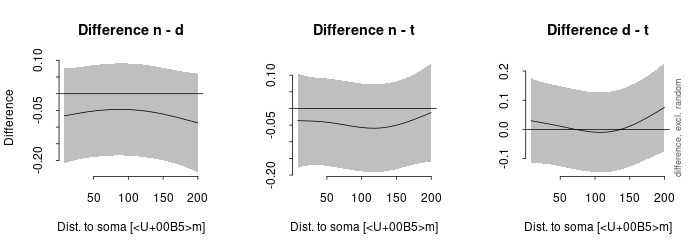

In [52]:
%%R -w 700 -h 250 -o nd_diff -o nt_diff -o dt_diff

#pdf("./figures/rf_size_differences.pdf", width=7, height=3)
n_diffs <- 3
par(mfrow=c(1, n_diffs), cex=1.0, tcl=-0.2)

se <- qnorm((100 - (2.5/n_diffs))/100)
print((100 - (2.5/n_diffs))/100)
print(se)
ylim <- NULL#c(-150, 150)
ylab <- 'Difference'
xlab <- 'Dist. to soma [µm]'

nd_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("n", "d")), se=se, ylab=ylab, xlab=xlab, ylim=ylim, hide.label=TRUE)
nt_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("n", "t")), se=se, ylab='', xlab=xlab, ylim=ylim, hide.label=TRUE)
dt_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("d", "t")), se=se, ylab='', xlab=xlab, ylim=ylim)
#dev.off()

In [53]:
pairs_sig_regions = [
    ("n vs. d  ", get_sig_intervals(nd_diff)),
    ("n vs. t  ", get_sig_intervals(nt_diff)),
    ("d vs. t  ", get_sig_intervals(dt_diff)),
]
pairs_sig_regions

[]
[]
[]
[]
[]
[]


[('n vs. d  ', []), ('n vs. t  ', []), ('d vs. t  ', [])]

# Go back to python for easy plotting

In [54]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

with localconverter(ro.default_converter + pandas2ri.converter):
    df_pred = ro.conversion.rpy2py(ro.globalenv['r_df_pred'])

In [55]:
df_pred.head()

,group,soma_dist,cell_id,fit,se.fit
1,d,7.623390,2018-06-10_1,0.001431,0.043204
2,n,7.623390,2018-06-10_1,-0.065070,0.040929
3,t,7.623390,2018-06-10_1,-0.028396,0.042857
4,d,11.545219,2018-06-10_1,0.003643,0.043088
5,n,11.545219,2018-06-10_1,-0.061352,0.040347


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(2.5, 1.8)


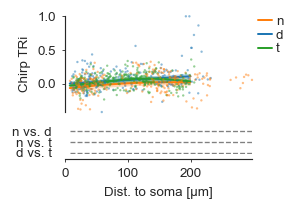

In [56]:
fig, axs = utils.plot_fits(
    df=df,
    df_preds=[df_pred],
    pairs_sig_regions_list=[pairs_sig_regions],
    titles=[None],
    ys=['chirp_tri'],
    ylabels=['Chirp TRi'],
    x='soma_dist',
    xlabel='Dist. to soma [µm]',
    order=order, colors=colors,
    figsize=(2.5, 1.8), ms=2, ma=0.5
)
axs[0].set_yticks([0, 0.5, 1])
plt.tight_layout()
plt.savefig(f'figures/{indicator}_chirp_tri_soma_dist.pdf')
plt.show()